In [1]:
import os, sys
import time

os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['PYSPARK_PYTHON'] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType, IntegerType, FloatType, LongType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StringIndexerModel, IndexToString
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


In [2]:
# Spark Session for Mongo
spark = SparkSession.builder \
    .appName("RL") \
    .config("spark.mongodb.connection.uri", "mongodb://127.0.0.1:27017") \
    .config("spark.mongodb.database", "RL_db") \
    .config("spark.mongodb.collection", "RL_collection") \
    .config("spark.jars.packages",
            "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0") \
    .getOrCreate()


:: loading settings :: url = jar:file:/home/vboxuser/spark-env/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/vboxuser/.ivy2/cache
The jars for the packages stored in: /home/vboxuser/.ivy2/jars
org.mongodb.spark#mongo-spark-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-417153a4-44f0-4dc8-b712-5dbb820f6f9b;1.0
	confs: [default]
	found org.mongodb.spark#mongo-spark-connector_2.12;10.3.0 in central
	found org.mongodb#mongodb-driver-sync;4.8.2 in central
	[4.8.2] org.mongodb#mongodb-driver-sync;[4.8.1,4.8.99)
	found org.mongodb#bson;4.8.2 in central
	found org.mongodb#mongodb-driver-core;4.8.2 in central
	found org.mongodb#bson-record-codec;4.8.2 in central
:: resolution report :: resolve 1658ms :: artifacts dl 12ms
	:: modules in use:
	org.mongodb#bson;4.8.2 from central in [default]
	org.mongodb#bson-record-codec;4.8.2 from central in [default]
	org.mongodb#mongodb-driver-core;4.8.2 from central in [default]
	org.mongodb#mongodb-driver-sync;4.8.2 from central in [default]
	org.mongodb.spark#mongo-spark-conne

In [3]:
# Check connection
try:
    # df = spark.read.format("mongodb").load()

    df = spark.read.format("mongodb") \
    .option("database", "RL_db") \
    .option("collection", "RL_collection") \
    .load()
  
    df.show(1)
    print("Connection successful!")
except Exception as e:
    print(f"Connection failed: {e}")

26/03/28 16:28:30 WARN Partitioner: Unable to get collection stats (collstats) returning a single partition.
26/03/28 16:28:30 WARN Partitioner: Unable to get collection stats (collstats) returning a single partition.


++
||
++
++

Connection successful!


In [4]:
# Libraries
from pyspark.sql.functions import col, sum, when
from pyspark.sql.types import DoubleType, IntegerType, FloatType, LongType
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [5]:
# Load and Clean Data
df = spark.read.csv(
    "/home/vboxuser/Big Data Systems Design/Afeena Final Project/Cleaned_Bikes.csv",
    header=True,
    inferSchema=True
)

df = df.filter(col("STATUS") == "STOLEN").drop("STATUS")

In [6]:
# Balance the Dataset
df_low = df.filter(col("RISK_LEVEL") == "Low").cache()
df_med = df.filter(col("RISK_LEVEL") == "Medium").cache()
df_high = df.filter(col("RISK_LEVEL") == "High").cache()

low_count = df_low.count()
med_count = df_med.count()
high_count = df_high.count()

target_count = 2000

df_low_bal = df_low.sample(withReplacement=True, fraction=target_count / low_count, seed=42).limit(target_count)
df_med_bal = df_med.sample(withReplacement=True, fraction=target_count / med_count, seed=42).limit(target_count)
df_high_bal = df_high.sample(withReplacement=True, fraction=target_count / high_count, seed=42).limit(target_count)

df_final = df_low_bal.union(df_med_bal).union(df_high_bal)

df_final = df_final.cache()
df_final.count()

print("Balanced Distribution:")
df_final.groupBy("RISK_LEVEL").count().show()

26/03/28 16:29:07 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Balanced Distribution:
+----------+-----+
|RISK_LEVEL|count|
+----------+-----+
|       Low| 1991|
|    Medium| 1993|
|      High| 2000|
+----------+-----+



In [7]:
# Checking again that my cleaned data has no nulls
from pyspark.sql.functions import col
from pyspark.sql.functions import *

null_counts = df_final.select([sum(col(c).isNull().cast("int")).alias(c) for c in df_final.columns])

#print full results with column names
null_counts.show(truncate=False)

+-----------------+---------------+--------+---------+-------+-------+-------+--------+-----------+------------+----------+----------+----------+-----------+--------+-------------+-------------+---------+----------+-----------+---------+--------+--------+-----------------+----------+---------+---+---+----------------+----------+----------+---------+
|NEIGHBOURHOOD_158|PRIMARY_OFFENCE|OCC_YEAR|OCC_MONTH|OCC_DOW|OCC_DAY|OCC_DOY|OCC_HOUR|REPORT_YEAR|REPORT_MONTH|REPORT_DOW|REPORT_DAY|REPORT_DOY|REPORT_HOUR|DIVISION|LOCATION_TYPE|PREMISES_TYPE|BIKE_TYPE|BIKE_SPEED|BIKE_COLOUR|BIKE_COST|HOOD_158|HOOD_140|NEIGHBOURHOOD_140|LONG_WGS84|LAT_WGS84|x  |y  |OCCURENCE_PERIOD|RISK_LEVEL|BIKE_MODEL|BIKE_MAKE|
+-----------------+---------------+--------+---------+-------+-------+-------+--------+-----------+------------+----------+----------+----------+-----------+--------+-------------+-------------+---------+----------+-----------+---------+--------+--------+-----------------+----------+---------+--

In [8]:
# Feature

numeric_types = (DoubleType, IntegerType, FloatType, LongType)

numeric_cols = [
    field.name for field in df_final.schema.fields
    if isinstance(field.dataType, numeric_types)
]

categorical_cols = [
    field.name for field in df_final.schema.fields
    if field.name not in numeric_cols
]

target_col = "RISK_LEVEL"

In [9]:
# Leaky Features
leaky_cols = [
    "y", "x", "LAT_WGS84", "LONG_WGS84",
    "HOOD_140", "NEIGHBOURHOOD_140",
    "HOOD_158", "NEIGHBOURHOOD_158"
]

In [10]:
# Build Pipeline

def build_pipeline(drop_leakage=False):

    if drop_leakage:
        numeric_features = [c for c in numeric_cols if c != target_col and c not in leaky_cols]
        categorical_features = [c for c in categorical_cols if c != target_col and c not in leaky_cols]
    else:
        numeric_features = [c for c in numeric_cols if c != target_col]
        categorical_features = [c for c in categorical_cols if c != target_col]

    indexers = [
        StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
        for c in categorical_features
    ]

    label_indexer = StringIndexer(
        inputCol=target_col,
        outputCol="label",
        stringOrderType="alphabetAsc"
    )

    assembler_inputs = [c + "_idx" for c in categorical_features] + numeric_features

    assembler = VectorAssembler(
        inputCols=assembler_inputs,
        outputCol="features"
    )

    # RANDOM FOREST
    rf = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        numTrees=200,
        maxDepth=15,
        maxBins=300,
        minInstancesPerNode=5,
        seed=42
    )

    pipeline = Pipeline(stages=indexers + [label_indexer, assembler, rf])

    return pipeline


In [11]:
# Train Model
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

train_data = train_data.cache()
test_data = test_data.cache()


In [12]:
# Model A with Leakage
print("\n===== MODEL A: WITH LOCATION FEATURES =====")

pipeline_A = build_pipeline(drop_leakage=False)
model_A = pipeline_A.fit(train_data)

pred_A = model_A.transform(test_data)

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

print(f"Accuracy: {evaluator.evaluate(pred_A, {evaluator.metricName: 'accuracy'}):.2%}")
print(f"Precision: {evaluator.evaluate(pred_A, {evaluator.metricName: 'weightedPrecision'}):.2%}")
print(f"F1 Score: {evaluator.evaluate(pred_A, {evaluator.metricName: 'f1'}):.2%}")

print("Confusion Matrix:")
pred_A.groupBy("label", "prediction").count().orderBy("label").show()



===== MODEL A: WITH LOCATION FEATURES =====


26/03/28 16:30:40 WARN DAGScheduler: Broadcasting large task binary with size 1421.3 KiB
26/03/28 16:30:43 WARN DAGScheduler: Broadcasting large task binary with size 1927.2 KiB
26/03/28 16:30:46 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/03/28 16:30:49 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
26/03/28 16:30:50 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
26/03/28 16:30:52 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/03/28 16:30:53 WARN DAGScheduler: Broadcasting large task binary with size 1983.2 KiB
26/03/28 16:30:54 WARN DAGScheduler: Broadcasting large task binary with size 1130.7 KiB
26/03/28 16:30:57 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
                                                                                

Accuracy: 100.00%


26/03/28 16:30:59 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


Precision: 100.00%


26/03/28 16:31:00 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


F1 Score: 100.00%
Confusion Matrix:


26/03/28 16:31:01 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|  410|
|  1.0|       1.0|  356|
|  2.0|       2.0|  395|
+-----+----------+-----+



26/03/28 16:31:01 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


In [13]:
#Model B withoug leakage
print("\n===== MODEL B: WITHOUT LOCATION FEATURES =====")

pipeline_B = build_pipeline(drop_leakage=True)
model_B = pipeline_B.fit(train_data)

pred_B = model_B.transform(test_data)

print(f"Accuracy: {evaluator.evaluate(pred_B, {evaluator.metricName: 'accuracy'}):.2%}")
print(f"Precision: {evaluator.evaluate(pred_B, {evaluator.metricName: 'weightedPrecision'}):.2%}")
print(f"F1 Score: {evaluator.evaluate(pred_B, {evaluator.metricName: 'f1'}):.2%}")

print("Confusion Matrix:")
pred_B.groupBy("label", "prediction").count().orderBy("label").show()


===== MODEL B: WITHOUT LOCATION FEATURES =====


26/03/28 16:32:06 WARN DAGScheduler: Broadcasting large task binary with size 1296.2 KiB
26/03/28 16:32:11 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/03/28 16:32:16 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/03/28 16:32:22 WARN DAGScheduler: Broadcasting large task binary with size 4.8 MiB
26/03/28 16:32:28 WARN DAGScheduler: Broadcasting large task binary with size 6.9 MiB
26/03/28 16:32:35 WARN DAGScheduler: Broadcasting large task binary with size 9.3 MiB
26/03/28 16:32:39 WARN DAGScheduler: Broadcasting large task binary with size 1133.6 KiB
26/03/28 16:32:43 WARN DAGScheduler: Broadcasting large task binary with size 11.9 MiB
26/03/28 16:32:47 WARN DAGScheduler: Broadcasting large task binary with size 1215.1 KiB
26/03/28 16:32:50 WARN DAGScheduler: Broadcasting large task binary with size 14.4 MiB
26/03/28 16:32:55 WARN DAGScheduler: Broadcasting large task binary with size 1159.8 KiB
26/03/28 16:32:59 WARN DAGScheduler: Bro

Accuracy: 89.15%


26/03/28 16:33:23 WARN DAGScheduler: Broadcasting large task binary with size 10.3 MiB
                                                                                

Precision: 91.29%


26/03/28 16:33:24 WARN DAGScheduler: Broadcasting large task binary with size 10.3 MiB
                                                                                

F1 Score: 88.99%
Confusion Matrix:


26/03/28 16:33:26 WARN DAGScheduler: Broadcasting large task binary with size 10.3 MiB
26/03/28 16:33:28 WARN DAGScheduler: Broadcasting large task binary with size 10.3 MiB


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       1.0|    3|
|  0.0|       0.0|  295|
|  0.0|       2.0|  112|
|  1.0|       1.0|  352|
|  1.0|       2.0|    4|
|  2.0|       0.0|    1|
|  2.0|       2.0|  388|
|  2.0|       1.0|    6|
+-----+----------+-----+



In [14]:
# Model Evaluation 
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

def evaluate(pred, name):
    print(f"\n{name}")
    print(f"Accuracy: {evaluator.evaluate(pred, {evaluator.metricName: 'accuracy'}):.2%}")
    print(f"Precision: {evaluator.evaluate(pred, {evaluator.metricName: 'weightedPrecision'}):.2%}")
    print(f"F1: {evaluator.evaluate(pred, {evaluator.metricName: 'f1'}):.2%}")
    pred.groupBy("label","prediction").count().orderBy("label").show()

evaluate(pred_A, "Model A")
evaluate(pred_B, "Model B")


Model A


26/03/28 16:33:51 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


Accuracy: 100.00%


26/03/28 16:33:52 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


Precision: 100.00%


...

Precision: 91.29%


26/03/28 16:33:57 WARN DAGScheduler: Broadcasting large task binary with size 10.3 MiB
                                                                                

F1: 88.99%


26/03/28 16:33:59 WARN DAGScheduler: Broadcasting large task binary with size 10.3 MiB
26/03/28 16:34:00 WARN DAGScheduler: Broadcasting large task binary with size 10.3 MiB


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       1.0|    3|
|  0.0|       0.0|  295|
|  0.0|       2.0|  112|
|  1.0|       1.0|  352|
|  1.0|       2.0|    4|
|  2.0|       0.0|    1|
|  2.0|       2.0|  388|
|  2.0|       1.0|    6|
+-----+----------+-----+



26/03/28 16:34:06 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/03/28 16:34:06 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


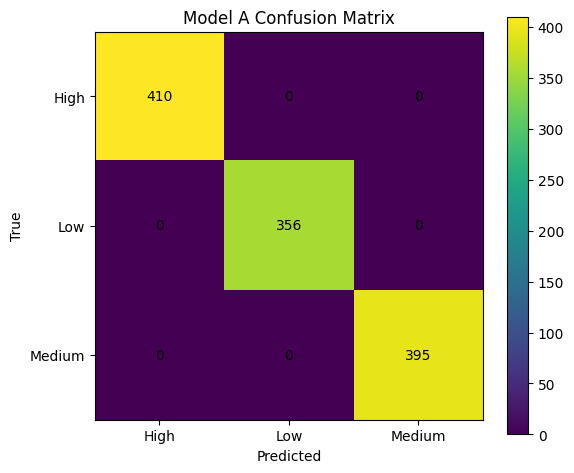

26/03/28 16:34:07 WARN DAGScheduler: Broadcasting large task binary with size 10.3 MiB
26/03/28 16:34:09 WARN DAGScheduler: Broadcasting large task binary with size 10.3 MiB
                                                                                

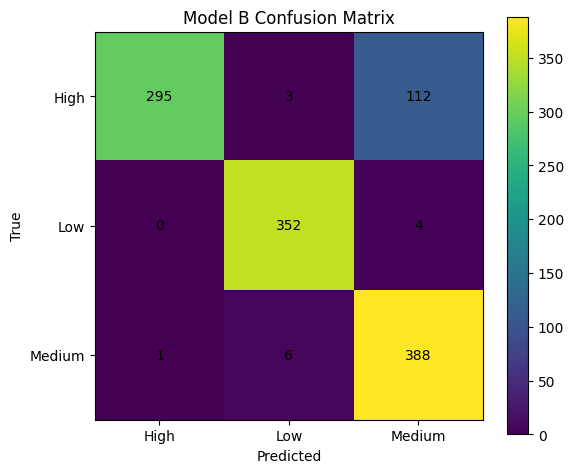

In [15]:
# plot a graph of the confusion matrix
import matplotlib.pyplot as plt

labels = ["High", "Low", "Medium"]

def plot_cm(pred_df, title):
    cm = np.zeros((3,3))
    for r in pred_df.groupBy("label","prediction").count().collect():
        cm[int(r["label"])][int(r["prediction"])] = r["count"]

    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xticks(range(3), labels)
    plt.yticks(range(3), labels)

    for i in range(3):
        for j in range(3):
            plt.text(j, i, int(cm[i,j]), ha='center', va='center')

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_cm(pred_A, "Model A Confusion Matrix")
plot_cm(pred_B, "Model B Confusion Matrix")


In [16]:
## Stream setup
input_dir = "/home/vboxuser/Big Data Systems Design/Afeena Final Project/synthetic_stream_data/"
# output_csv_path = "/home/vboxuser/Big Data Systems Design/Afeena Final Project/synthetic_with_predictions"

# Get correct schema order
temp_df = spark.read.option("header", "true").csv(input_dir).limit(1)
correct_schema = temp_df.schema

raw_stream_df = spark.readStream \
    .format("csv") \
    .option("header", "true") \
    .schema(correct_schema) \
    .load(input_dir)


In [18]:
# Apply Model
stream_df = raw_stream_df

numeric_features = [c for c in numeric_cols if c not in leaky_cols and c != target_col]
categorical_features = [c for c in categorical_cols if c not in leaky_cols and c != target_col]

# Apply Model B
active_model = model_B

# Cast numeric columns
for c in numeric_features:
    stream_df = stream_df.withColumn(c, col(c).cast("double"))

# Remove label indexer (RISK_LEVEL not in stream)
feature_stages = [
    s for s in active_model.stages
    if not (isinstance(s, StringIndexerModel) and s.getInputCol() == "RISK_LEVEL")
]

# Apply transformations
predictions_stream = stream_df
for stage in feature_stages:
    predictions_stream = stage.transform(predictions_stream)

# Convert prediction index → label
label_indexer_model = [
    s for s in active_model.stages
    if isinstance(s, StringIndexerModel) and s.getInputCol() == "RISK_LEVEL"
][0]

label_converter = IndexToString(
    inputCol="prediction",
    outputCol="Predicted_Risk_Level",
    labels=label_indexer_model.labels
)

final_stream = label_converter.transform(predictions_stream)


In [19]:
# Remove/ convert unsupported columns

from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, DoubleType

# Convert probability vector → array
vector_to_array = udf(lambda v: v.toArray().tolist(), ArrayType(DoubleType()))

final_stream = final_stream.withColumn(
    "probability_array",
    vector_to_array(col("probability"))
)

# Drop unsupported columns
final_stream = final_stream.drop("features", "rawPrediction", "probability")


In [21]:
# ## Write to MongoDB
# mongo_query = final_stream.writeStream \
#     .format("mongodb") \
#     .option("checkpointLocation", "/tmp/checkpoint_mongo") \
#     .outputMode("append") \
#     .start()

## Write to MongoDB
mongo_query = final_stream.writeStream \
    .format("mongodb") \
    .option("checkpointLocation", "/tmp/checkpoint_mongo") \
    .option("spark.mongodb.connection.uri", "mongodb://127.0.0.1:27017") \
    .option("spark.mongodb.database", "RL_db") \
    .option("spark.mongodb.collection", "RL_collection") \
    .outputMode("append") \
    .start()
    # .outputMode("overwrite") \


26/03/28 16:39:29 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
26/03/28 16:39:30 WARN CaseInsensitiveStringMap: Converting duplicated key checkpointLocation into CaseInsensitiveStringMap.
26/03/28 16:39:30 WARN CaseInsensitiveStringMap: Converting duplicated key checkpointLocation into CaseInsensitiveStringMap.
26/03/28 16:39:30 WARN CaseInsensitiveStringMap: Converting duplicated key checkpointLocation into CaseInsensitiveStringMap.
26/03/28 16:39:31 WARN DAGScheduler: Broadcasting large task binary with size 10.3 MiB
                                                                                

In [ ]:
# Write to csv
# csv_query = final_stream.writeStream \
#     .format("csv") \
#     .option("path", output_csv_path) \
#     .option("header", True) \
#     .option("checkpointLocation", "/tmp/checkpoint_csv") \
#     .outputMode("append") \
#     .start()


# Write to Parquet, csv not working b/c of array value
output_parquet_path = "/home/vboxuser/Big Data Systems Design/Afeena Final Project/synthetic_with_predictions_parquet3"

parquet_query = final_stream.writeStream \
    .format("parquet") \
    .option("path", output_parquet_path) \
    .option("checkpointLocation", "/tmp/checkpoint_parquet3") \
    .outputMode("append") \
    .start()

print("Streaming started... Press Ctrl+C to stop.")
mongo_query.awaitTermination()
parquet_query.awaitTermination()

26/03/28 16:44:39 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


Streaming started... Press Ctrl+C to stop.


26/03/28 16:44:41 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
                                                                                

In [ ]:
## Run stream- At this time it's more POC
print("Streaming started...")

time.sleep(5)   # process small batch only

mongo_query.stop()
# csv_query.stop()

print("Streaming complete. Data written to MongoDB and parquet.")

In [ ]:
# Stop Spark Streaming
spark.stop()